# Robust PCA
## Problem

We want to solve

$$\min\limits_{X\in\mathbb{R}^{n\times m}} f(X) + \|X\|_1$$
where 
$$\mathcal{C} = \{U\in\mathbb{R}^{n\times m}\colon \|U\|_*\leq \rho\}$$

is the set of $n\times m$ matrices with nuclear norm less than $\rho$.

We will take 

$$f(X) := \sum\limits_{i,j\in [[p,q]]}f_0(\mathcal{A}(X)_{i,j} - b_{i,j})$$

for some linear operator $\mathcal{A}\colon\mathbb{R}^{n\times m}\to \mathbb{R}^{p\times q}$ which gives us the observed pixels in the form of a subimage of size $p\times q$ and for the function $f_0\colon\mathbb{R}\to\mathbb{R}$ given by

$$f_0(x) = \frac{x^2}{2\delta^2 + x^2}$$

for some small $\delta>0$.

The derivative of $f_0$ is given by

$$f_0'(x) = \frac{4\delta^2 x}{(2\delta^2 + x^2)^2}$$

The nonsmooth function $g$ will be taken to be

$$g(X) = \iota_{[0,1]^{n\times m}}(X)$$

whose projection is just clamping componentwise to $[0,1]$.

In [12]:
import numpy as np
import fw_functions as fw
from PIL import Image
import matplotlib.pyplot as plt

In [13]:
# Load the grayscale image
image = np.array(Image.open('house.jpg').convert('L')) / 255
# Get the dimensions of the image
height, width = image.shape

In [14]:
# Create a mask for inpainting
observed_indices_mask = np.zeros((height, width), dtype=bool)
p = int(0.9 * height)
q = int(0.9 * width)
num_observed_pixels = p * q
# Draw random subset of pixels
observed_indices = np.random.choice(height * width, num_observed_pixels, replace=False)
rows, cols = np.unravel_index(observed_indices, (height, width))
# Set the selected pixels in the mask to True
observed_indices_mask[rows, cols] = True
observations = image[observed_indices_mask]

In [15]:
# Create a mask for inpainting
observed_indices_mask = np.ones((height, width), dtype=bool)

# Generate 25 squares of size 5x5
num_squares = 100
square_size = 20

num_observed_pixels = num_squares * (square_size**2)

for _ in range(num_squares):
    # Randomly select the top-left corner of the square
    top_left_row = np.random.randint(0, height - square_size + 1)
    top_left_col = np.random.randint(0, width - square_size + 1)
    
    # Create a slice for the square region
    square_slice = np.s_[top_left_row:top_left_row+square_size, top_left_col:top_left_col+square_size]
    
    # Set the pixels in the square region to False (masked)
    observed_indices_mask[square_slice] = False

observations = image[observed_indices_mask]

In [16]:
# Create a copy of the image for adding noise
noisy_image = np.copy(image)
# Apply salt and pepper noise with density 1/10
noise_density = 0.1
num_salt = np.ceil(noise_density * num_observed_pixels)
num_pepper = num_salt
# Add salt noise (white pixels) to the observed pixels
salt_indices = np.random.choice(num_observed_pixels, int(num_salt), replace=False)
salt_rows, salt_cols = rows[salt_indices], cols[salt_indices]
noisy_image[salt_rows, salt_cols] = 1.0
# Add pepper noise (black pixels) to the observed pixels
pepper_indices = np.random.choice(num_observed_pixels, int(num_pepper), replace=False)
pepper_rows, pepper_cols = rows[pepper_indices], cols[pepper_indices]
noisy_image[pepper_rows, pepper_cols] = 0.0 

In [17]:
# Create a copy of the image for adding noise
noisy_image = np.copy(image)

# Apply salt and pepper noise with density 1/10
noise_density = 0.1

# Compute the total number of pixels in the observed squares
num_observed_pixels = np.sum(observed_indices_mask)

# Compute the number of salt and pepper pixels based on the noise density
num_salt = np.ceil(noise_density * num_observed_pixels)
num_pepper = num_salt

# Find the indices of the observed pixels in the squares
observed_indices = np.nonzero(observed_indices_mask)

# Randomly select pixels for salt noise within the observed squares
salt_indices = np.random.choice(np.arange(num_observed_pixels), int(num_salt), replace=False)
salt_rows, salt_cols = observed_indices[0][salt_indices], observed_indices[1][salt_indices]
noisy_image[salt_rows, salt_cols] = 1.0

# Randomly select pixels for pepper noise within the observed squares
pepper_indices = np.random.choice(np.arange(num_observed_pixels), int(num_pepper), replace=False)
pepper_rows, pepper_cols = observed_indices[0][pepper_indices], observed_indices[1][pepper_indices]
noisy_image[pepper_rows, pepper_cols] = 0.0

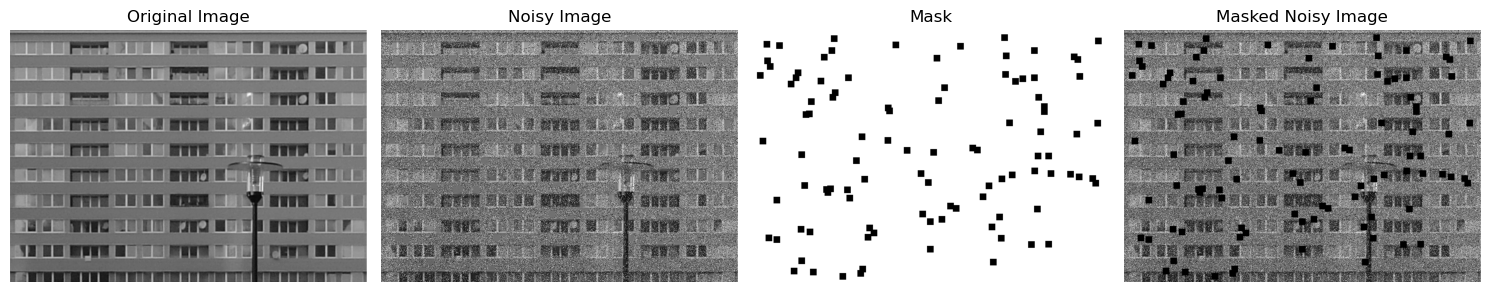

In [18]:
# Display the original image, noisy image, mask, and masked noisy image
fig, axs = plt.subplots(1, 4, figsize=(15, 5))
axs[0].imshow(image, cmap='gray')
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(noisy_image, cmap='gray')
axs[1].set_title('Noisy Image')
axs[1].axis('off')
axs[2].imshow(observed_indices_mask, cmap='gray')
axs[2].set_title('Mask')
axs[2].axis('off')
axs[3].imshow(noisy_image * observed_indices_mask, cmap='gray')  # Multiply noisy_image with mask
axs[3].set_title('Masked Noisy Image')
axs[3].axis('off')
plt.tight_layout()
plt.show()
plt.close()  # Close the figure after displaying it

In [19]:
class RobustPCAObjective(fw.ObjectiveFunction):
    def __init__(self, delta, observed_indices_mask, observations):
        self.delta = delta
        self.observed_indices_mask = observed_indices_mask
        self.observations = observations
    
    def evaluate(self, X):
        X_observed = X[self.observed_indices_mask]
        diff = X_observed - self.observations
        return (diff**2/(2*(self.delta**2) + diff**2)).sum()
    
    def gradient(self, X):
        X_observed = X[self.observed_indices_mask]
        diff = X_observed - self.observations
        grad_observed = 4 * diff * (self.delta ** 2) / ((2 * (self.delta ** 2) + (diff ** 2)) ** 2)
        grad = np.zeros_like(X)
        grad[self.observed_indices_mask] = grad_observed
        return grad
    
    def linear_operator(self, X):
        return X
    
    def linear_operator_adjoint(self, X):
        return X
    
    def minimal_norm_selection(self, X):
        return fw.l1_minimal_norm_selection(X)

In [20]:
observations = noisy_image[observed_indices_mask]
X0 = np.zeros_like(image)
#X0[observed_indices_mask] = observations

delta = 1.0

In [21]:
# Create the LMO function
radius = 2.0 * np.linalg.norm(image, ord='nuc')
constraint_set = 'nuclear_norm_ball'
lmo_fn = fw.create_lmo(radius, constraint_set)

# Create the prox function
def prox_fn(X, beta):
    return fw.soft_thresh(X, beta)

# Initialize the objective
objective_fn = RobustPCAObjective(delta, observed_indices_mask, observations)
objective_type = 'lipschitz'

# Create an instance of the FrankWolfe class
RobustPCA = fw.FrankWolfe(objective_fn, lmo_fn, prox_fn, objective_type)

In [22]:
# Run the algorithm
sol = RobustPCA.run(X0, beta0=1e0, n_steps=int(1e3))

Frank-Wolfe Progress: 100%|██████████| 1000/1000 [01:10<00:00, 14.21it/s]


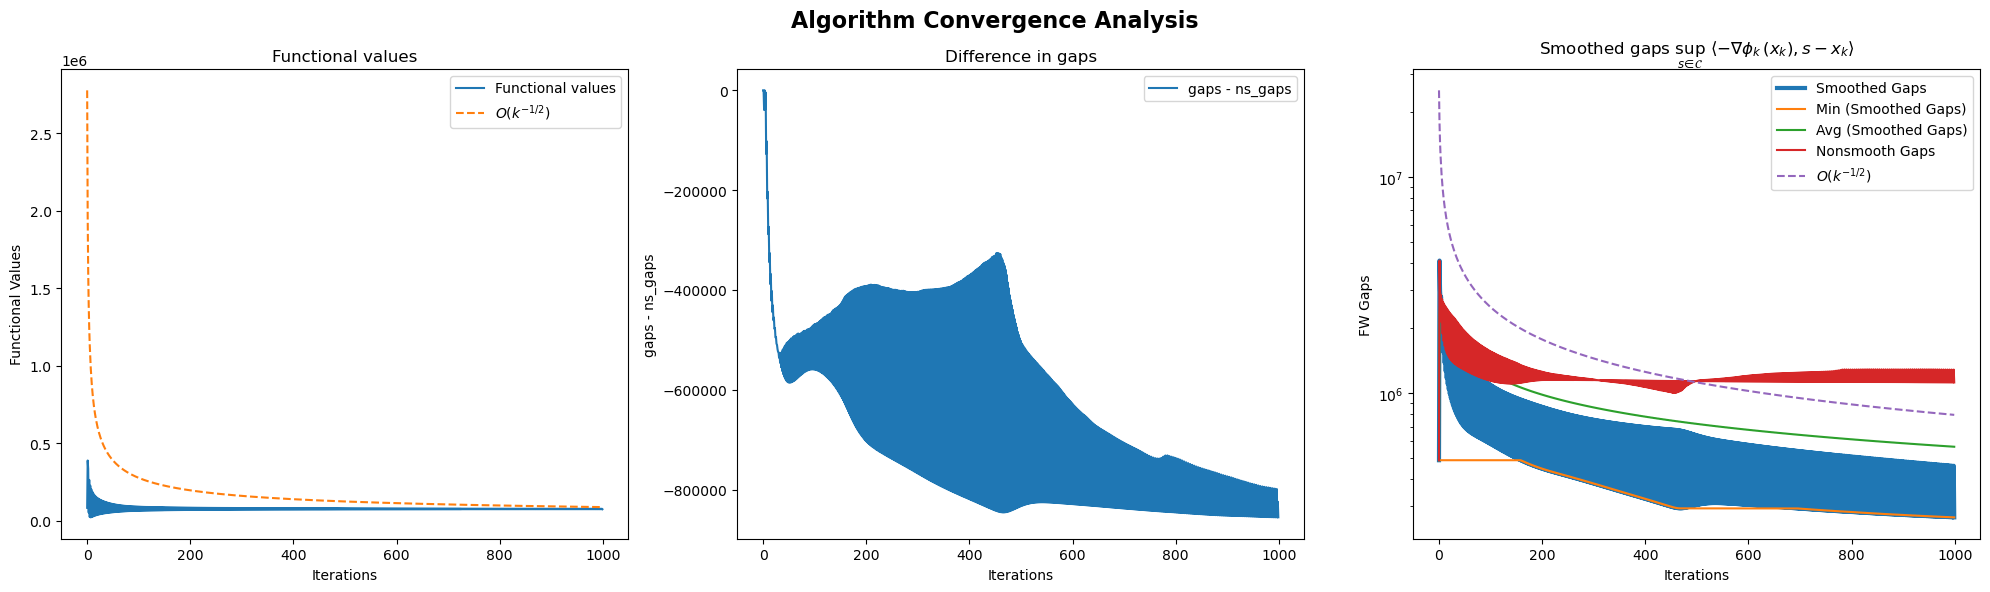

In [23]:
# Plot the convergence results
RobustPCA.plot_convergence()

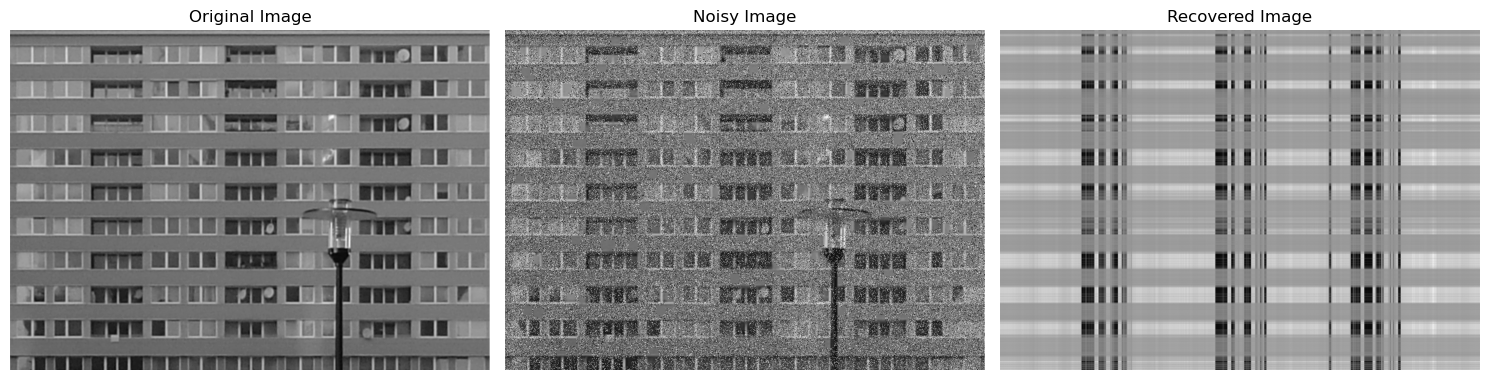

In [24]:
# Display the original image and the solution
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(image, cmap='gray')
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(noisy_image, cmap='gray')
axs[1].set_title('Noisy Image')
axs[1].axis('off')
axs[2].imshow(sol, cmap='gray')
axs[2].set_title('Recovered Image')
axs[2].axis('off')
plt.tight_layout()
plt.show()
plt.close()  # Close the figure after displaying it